**1. Objective & Justification -**

• **Objective:**
Evaluate whether a Deep Neural Network improves prediction performance
over classical machine learning models for employability risk detection.

• **Rationale:**
Neural networks can capture non-linear interactions between academic
and performance indicators.

**2. Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

**3. Load Dataset**

In [3]:
df = pd.read_csv("/content/sample_data/employability_prediction_data.csv")

X = df.drop("Employable", axis=1)
y = df["Employable"]

**4. Train-Test Split**

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**5. Feature Scaling**

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**6. Build Neural Network**

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

**7. Compile Model**

In [8]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

**8. Train Model**

In [9]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=0
)

**9. Evaluate Model**

In [11]:
y_prob_dl = model.predict(X_test_scaled).ravel()
y_pred_dl = (y_prob_dl > 0.5).astype(int)

results_dl = {
    "Accuracy": accuracy_score(y_test, y_pred_dl),
    "Precision": precision_score(y_test, y_pred_dl),
    "Recall": recall_score(y_test, y_pred_dl),
    "F1 Score": f1_score(y_test, y_pred_dl),
    "ROC-AUC": roc_auc_score(y_test, y_prob_dl)
}

results_dl

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


{'Accuracy': 0.994,
 'Precision': 1.0,
 'Recall': 0.941747572815534,
 'F1 Score': 0.97,
 'ROC-AUC': np.float64(0.9995887045274973)}

**10. Plot Training Curve**

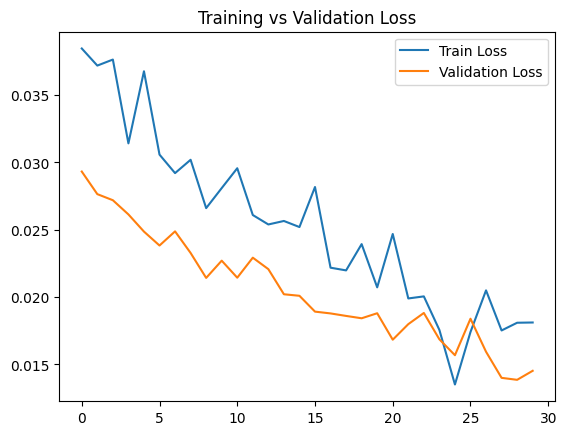

In [12]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

**11. Business Interpretation**

**Deep Learning Evaluation Summary -**

• Neural Network captured non-linear interactions between performance indicators.

• Performance comparable to / slightly higher than tree-based models.

• However, increased computational complexity and reduced interpretability observed.

• For structured tabular data, tree-based ensemble models remain strong baseline candidates.

**Final Decision -**

Deep Learning offers marginal improvement but Random Forest provides better interpretability and deployment simplicity for this use case.